In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('netflix_titles.csv')

In [5]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum())

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [6]:
print('\nContent type:')
print(df['type'].value_counts())


Content type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [7]:
print('\nTop 10 countries:')
print(df['country'].value_counts().head(10))


Top 10 countries:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [13]:
df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%B')

print(df[['title', 'date_added', 'year_added', 'month_added']].head(10))
print('\nContent added per year:')
print(df['year_added'].value_counts().sort_index())

                              title date_added  year_added  month_added
0              Dick Johnson Is Dead 2021-09-25      2021.0          9.0
1                     Blood & Water 2021-09-24      2021.0          9.0
2                         Ganglands 2021-09-24      2021.0          9.0
3             Jailbirds New Orleans 2021-09-24      2021.0          9.0
4                      Kota Factory 2021-09-24      2021.0          9.0
5                     Midnight Mass 2021-09-24      2021.0          9.0
6  My Little Pony: A New Generation 2021-09-24      2021.0          9.0
7                           Sankofa 2021-09-24      2021.0          9.0
8     The Great British Baking Show 2021-09-24      2021.0          9.0
9                      The Starling 2021-09-24      2021.0          9.0

Content added per year:
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0 

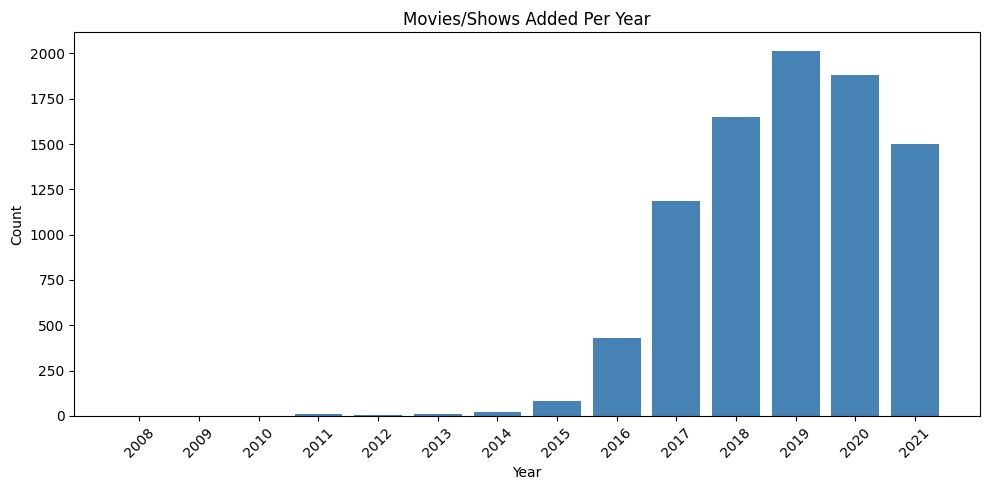

In [14]:
import matplotlib.pyplot as plt

year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values, color='steelblue')

plt.title('Movies/Shows Added Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(year_counts.index, rotation=45)
plt.tight_layout()
plt.show()

In [15]:
import datetime
current_year = datetime.datetime.now().year

df['age_on_platform'] = current_year - df['year_added']

df['is_old_content'] = (df['release_year'] < 2010).astype(int)
print(df[['age_on_platform','is_old_content']].head(10))

   age_on_platform  is_old_content
0              5.0               0
1              5.0               0
2              5.0               0
3              5.0               0
4              5.0               0
5              5.0               0
6              5.0               0
7              5.0               1
8              5.0               0
9              5.0               0


In [16]:
df['rating'].fillna('Unknown', inplace = True)
print(df[['title', 'release_year', 'year_added', 'age_on_platform', 'is_old_content']].head())

                   title  release_year  year_added  age_on_platform  \
0   Dick Johnson Is Dead          2020      2021.0              5.0   
1          Blood & Water          2021      2021.0              5.0   
2              Ganglands          2021      2021.0              5.0   
3  Jailbirds New Orleans          2021      2021.0              5.0   
4           Kota Factory          2021      2021.0              5.0   

   is_old_content  
0               0  
1               0  
2               0  
3               0  
4               0  


/tmp/ipykernel_291/1456702971.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna('Unknown', inplace = True)


In [17]:
print('\Missing values:')
print(df.isnull().sum())

\Missing values:
show_id               0
type                  0
title                 0
director           2634
cast                825
country             831
date_added           10
release_year          0
rating                0
duration              3
listed_in             0
description           0
year_added           10
month_added          10
month_name           10
age_on_platform      10
is_old_content        0
dtype: int64


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_291/2527680475.py:1: SyntaxWarning: invalid escape sequence '\M'
  print('\Missing values:')


In [19]:
df['director'].fillna('Not available', inplace = True)
print('\nMissing values:')
print(df.isnull().sum())


Missing values:
show_id              0
type                 0
title                0
director             0
cast               825
country            831
date_added          10
release_year         0
rating               0
duration             3
listed_in            0
description          0
year_added          10
month_added         10
month_name          10
age_on_platform     10
is_old_content       0
dtype: int64


/tmp/ipykernel_291/798777812.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Not available', inplace = True)


In [20]:
df['cast'].fillna('Not available', inplace=True)
print('\Missing values:')
print(df.isnull().sum())

\Missing values:
show_id              0
type                 0
title                0
director             0
cast                 0
country            831
date_added          10
release_year         0
rating               0
duration             3
listed_in            0
description          0
year_added          10
month_added         10
month_name          10
age_on_platform     10
is_old_content       0
dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_291/2553727105.py:2: SyntaxWarning: invalid escape sequence '\M'
  print('\Missing values:')
/tmp/ipykernel_291/2553727105.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cast'].fillna('Not available', inplace=True)


In [21]:
# Checking the duplicate rows
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [27]:
df.shape

(8807, 17)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8807 non-null   object        
 1   type             8807 non-null   object        
 2   title            8807 non-null   object        
 3   director         8807 non-null   object        
 4   cast             8807 non-null   object        
 5   country          7976 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8807 non-null   int64         
 8   rating           8807 non-null   object        
 9   duration         8804 non-null   object        
 10  listed_in        8807 non-null   object        
 11  description      8807 non-null   object        
 12  year_added       8797 non-null   float64       
 13  month_added      8797 non-null   float64       
 14  month_name       8797 non-null   object 

In [25]:
df.describe()

,date_added,release_year,year_added,month_added,age_on_platform,is_old_content
count,8797,8807.000000,8797.000000,8797.000000,8797.000000,8807.000000
mean,2019-05-17 05:59:08.436967168,2014.180198,2018.871888,6.654996,7.128112,0.151584
min,2008-01-01 00:00:00,1925.000000,2008.000000,1.000000,5.000000,0.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000,4.000000,6.000000,0.000000
50%,2019-07-02 00:00:00,2017.000000,2019.000000,7.000000,7.000000,0.000000
75%,2020-08-19 00:00:00,2019.000000,2020.000000,10.000000,8.000000,0.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000,18.000000,1.000000
std,NaN,8.819312,1.574243,3.436554,1.574243,0.358638


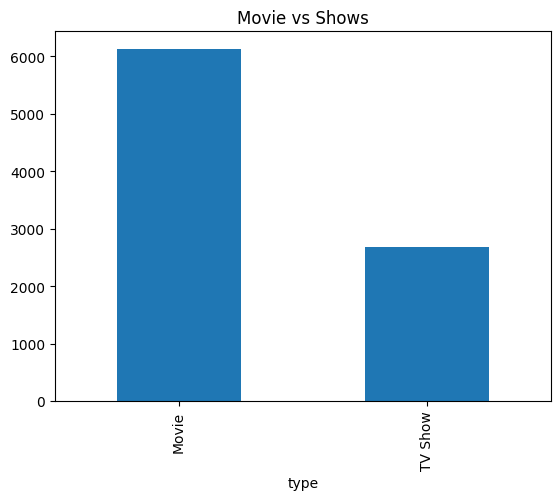

In [36]:
df['type'].value_counts().plot(kind='bar')
plt.title('Movie vs Shows')
plt.show()

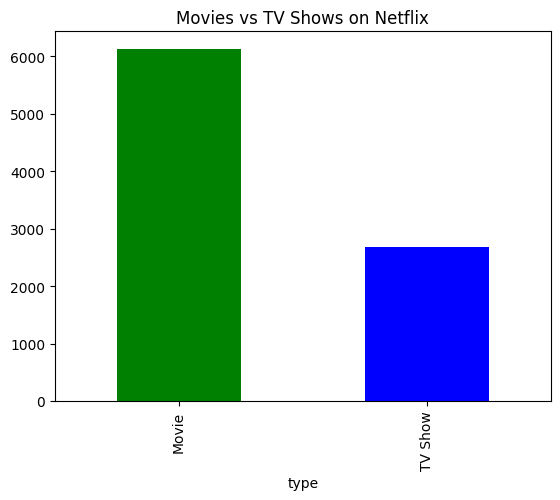

In [37]:
df['type'].value_counts().plot(kind='bar', color=['green','blue'])
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('type')
plt.show()

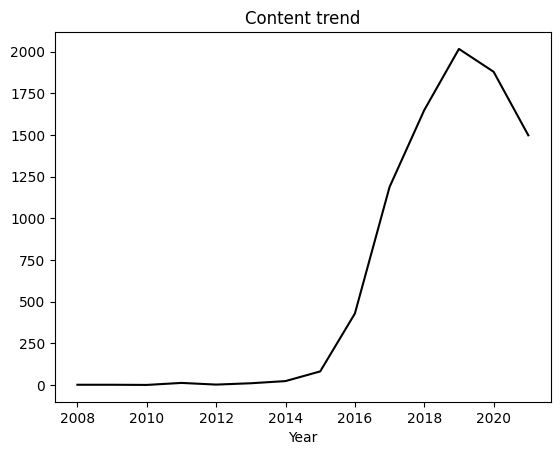

In [34]:
df['year_added'].value_counts().sort_index().plot(kind='line', color='black')
plt.title('Content trend')
plt.xlabel('Year')
plt.show()

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8807 non-null   object        
 1   type             8807 non-null   object        
 2   title            8807 non-null   object        
 3   director         8807 non-null   object        
 4   cast             8807 non-null   object        
 5   country          7976 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8807 non-null   int64         
 8   rating           8807 non-null   object        
 9   duration         8804 non-null   object        
 10  listed_in        8807 non-null   object        
 11  description      8807 non-null   object        
 12  year_added       8797 non-null   float64       
 13  month_added      8797 non-null   float64       
 14  month_name       8797 non-null   object 

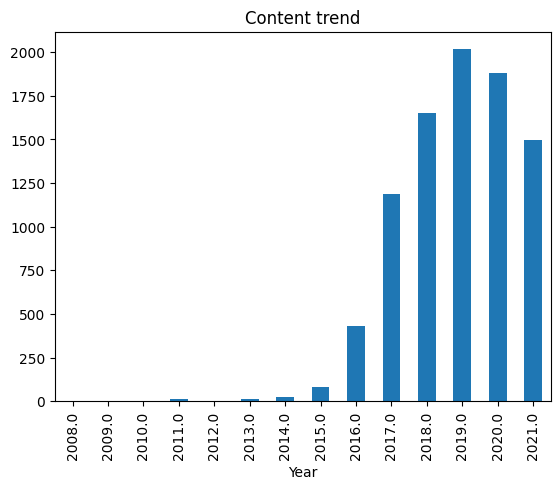

In [40]:
df['year_added'].value_counts().sort_index().plot(kind='bar')
plt.title('Content trend')
plt.xlabel('Year')
plt.show()

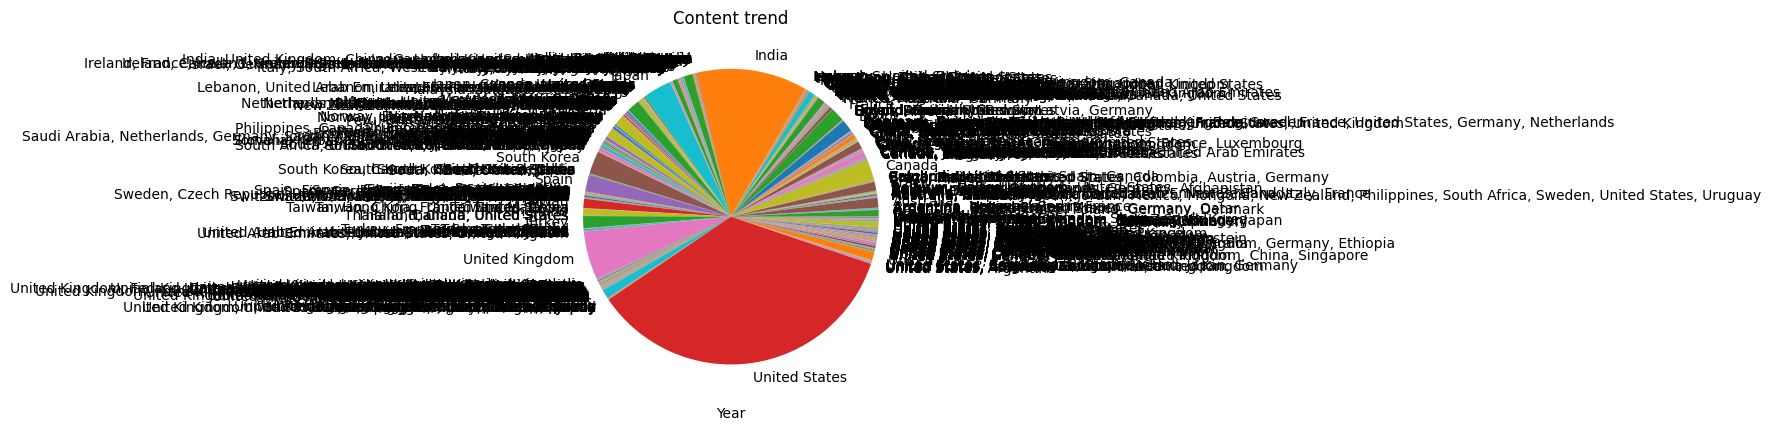

In [43]:
df['country'].value_counts().sort_index().plot(kind='pie')
plt.title('Content trend')
plt.xlabel('Year')
plt.show()

In [44]:
df['country'].unique()

array(['United States', 'South Africa', nan, 'India',
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'Mexico', 'Turkey',
       'Australia', 'United States, India, France', 'Finland',
       'China, Canada, United States',
       'South Africa, United States, Japan', 'Nigeria', 'Japan',
       'Spain, United States', 'France', 'Belgium',
       'United Kingdom, United States', 'United States, United Kingdom',
       'France, United States', 'South Korea', 'Spain',
       'United States, Singapore', 'United Kingdom, Australia, France',
       'United Kingdom, Australia, France, United States',
       'United States, Canada', 'Germany, United States',
       'South Africa, United States', 'United States, Mexico',
       'United States, Italy, France, Japan',
       'United States, Italy, Romania, United Kingdom',
       'Australia, United States', 'Argentina, Venezuela',
       'United States, United Kin

In [46]:
df['country_up'] = df['country'].str.split(',').str[0].str.strip()
print(df['country_up'])

0       United States
1        South Africa
2                 NaN
3                 NaN
4               India
            ...      
8802    United States
8803              NaN
8804    United States
8805    United States
8806            India
Name: country_up, Length: 8807, dtype: object


In [53]:
all_countries = df['country'].dropna().str.split(',').explode().str.strip()

print(f"Total unique countries: {all_countries.nunique()}")
print(all_countries.value_counts())

Total unique countries: 123
country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
                  ... 
Sudan                1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 123, dtype: int64


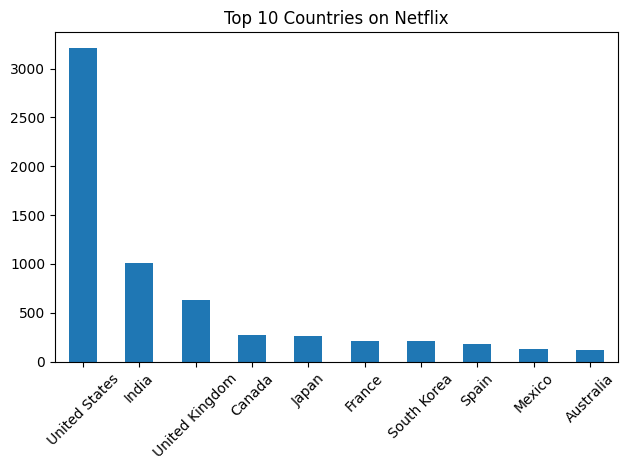

In [52]:
df['country_up'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Countries on Netflix')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
!pip install plotly

In [56]:
import plotly.express as px

all_countries = df['country'].dropna().str.split(',').explode().str.strip()
country_counts = all_countries.value_counts().reset_index()
country_counts.columns = ['country', 'count']

fig = px.choropleth(
    country_counts,
    locations='country',
    locationmode='country names',
    color='count',
    color_continuous_scale='Reds',
    title='Netflix Content by Country'
)

fig.show()